# Testing Out New Classes

In [ ]:
from utils_3 import PairwiseData

: 

In [ ]:
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k", )
ds = dict(ds)

/home/jennifer/distortion/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds

{'train': Dataset({
     features: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp'],
     num_rows: 135634
 })}

In [ ]:
pw = PairwiseData(ds, M=30, N=30)

In [ ]:
pw.winners

array([ 1, 26, 29, ..., 23, 21, 13], shape=(37454,))

In [ ]:
import numpy as np
subgroups, count = np.unique(pw.subgroups, return_counts=True)

In [ ]:
subgroups

array([   0,   64,   68,   76,   80,   92,   96,  100,  112,  124,  192,
        224,  240,  248,  252,  364,  366,  380,  382,  432,  508,  509,
        512, 1024, 1148, 1276, 1388, 1404, 1532, 1533], dtype=uint32)

In [ ]:
count

array([4091, 1620, 1588, 1249,  412,  616,  466,  760,  427,  515,  812,
        980, 1257, 1505, 1290,  712,  727, 1070,  489,  488, 2251, 2032,
        425,  480,  593, 1222,  424, 1949, 3995, 3009])

In [ ]:
len(subgroups)

30

In [ ]:
pw.candidates_to_idx

{np.str_('claude-opus-4-20250514'): 0,
 np.str_('gemini-2.5-pro'): 1,
 np.str_('gemini-2.5-flash'): 2,
 np.str_('qwen3-235b-a22b-no-thinking'): 3,
 np.str_('mistral-medium-2505'): 4,
 np.str_('o3-2025-04-16'): 5,
 np.str_('claude-sonnet-4-20250514'): 6,
 np.str_('chatgpt-4o-latest-20250326'): 7,
 np.str_('claude-3-7-sonnet-20250219-thinking-32k'): 8,
 np.str_('gemma-3-27b-it'): 9,
 np.str_('claude-3-7-sonnet-20250219'): 10,
 np.str_('claude-3-5-sonnet-20241022'): 11,
 np.str_('o3-mini'): 12,
 np.str_('command-a-03-2025'): 13,
 np.str_('deepseek-r1-0528'): 14,
 np.str_('claude-3-5-haiku-20241022'): 15,
 np.str_('gpt-4.1-2025-04-14'): 16,
 np.str_('o4-mini-2025-04-16'): 17,
 np.str_('claude-opus-4-20250514-thinking-16k'): 18,
 np.str_('amazon.nova-pro-v1:0'): 19,
 np.str_('grok-3-preview-02-24'): 20,
 np.str_('deepseek-v3-0324'): 21,
 np.str_('gpt-4.1-mini-2025-04-14'): 22,
 np.str_('llama-4-maverick-03-26-experimental'): 23,
 np.str_('gemini-2.0-flash-001'): 24,
 np.str_('grok-3-mini-be

In [ ]:
set(pw.subgroups)

{np.uint32(0),
 np.uint32(64),
 np.uint32(68),
 np.uint32(76),
 np.uint32(80),
 np.uint32(92),
 np.uint32(96),
 np.uint32(100),
 np.uint32(112),
 np.uint32(124),
 np.uint32(192),
 np.uint32(224),
 np.uint32(240),
 np.uint32(248),
 np.uint32(252),
 np.uint32(364),
 np.uint32(366),
 np.uint32(380),
 np.uint32(382),
 np.uint32(432),
 np.uint32(508),
 np.uint32(509),
 np.uint32(512),
 np.uint32(1024),
 np.uint32(1148),
 np.uint32(1276),
 np.uint32(1388),
 np.uint32(1404),
 np.uint32(1532),
 np.uint32(1533)}

In [ ]:
pw.data_by_subgroups([204])

{'winners': array([], dtype=int64),
 'losers': array([], dtype=int64),
 'subgroups': array([], dtype=uint32)}

In [ ]:
import numpy as np

s, c = np.unique(pw.subgroups, return_counts=True)

In [ ]:
np.sort(-c)

array([-4091, -3995, -3009, -2251, -2032, -1949, -1620, -1588, -1505,
       -1290, -1257, -1249, -1222, -1070,  -980,  -812,  -760,  -727,
        -712,  -616,  -593,  -515,  -489,  -488,  -480,  -466,  -427,
        -425,  -424,  -412])

In [ ]:
from utils_3 import Population

population = Population(pw)

100%|██████████| 30/30 [00:01<00:00, 29.00it/s]


In [ ]:
population.population_utilities

array([[ 2.10919469e-01,  7.35018703e-01,  3.87191957e-01,
         2.12698333e-01,  4.96900066e-01,  6.72888183e-01,
         9.80883584e-02,  8.42849654e-01,  1.96403400e-01,
         2.95988263e-01, -1.62029286e-01, -1.08227677e-01,
         1.35628560e-01,  1.39369777e-01,  6.50817858e-01,
         1.46343479e-02,  6.33032453e-01,  6.69978276e-01,
         7.55176691e-02, -2.61606899e-02,  8.64540225e-01,
         4.65483019e-01,  2.84565768e-01,  5.91858252e-01,
         2.91117983e-01,  2.45363201e-01,  1.29677718e-01,
         3.12061526e-01,  2.87435804e-02,  0.00000000e+00],
       [ 5.96115498e-01,  1.28439169e+00,  4.79053977e-01,
         6.21350214e-01,  5.24050112e-01,  1.14260234e+00,
         3.46530925e-02,  7.71771611e-01, -4.41598485e-01,
         5.16134517e-01, -1.13850630e-02,  3.15678261e-01,
        -4.33041538e-01,  3.31965771e-01,  1.18335420e+00,
        -7.13144584e-01,  6.72594304e-01,  4.46424412e-01,
         4.59859301e-01, -4.69228581e-01,  1.15196879e+

In [ ]:
population.population_utilities.shape

(30, 30)

30


/tmp/ipykernel_3355948/1490993664.py:19: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


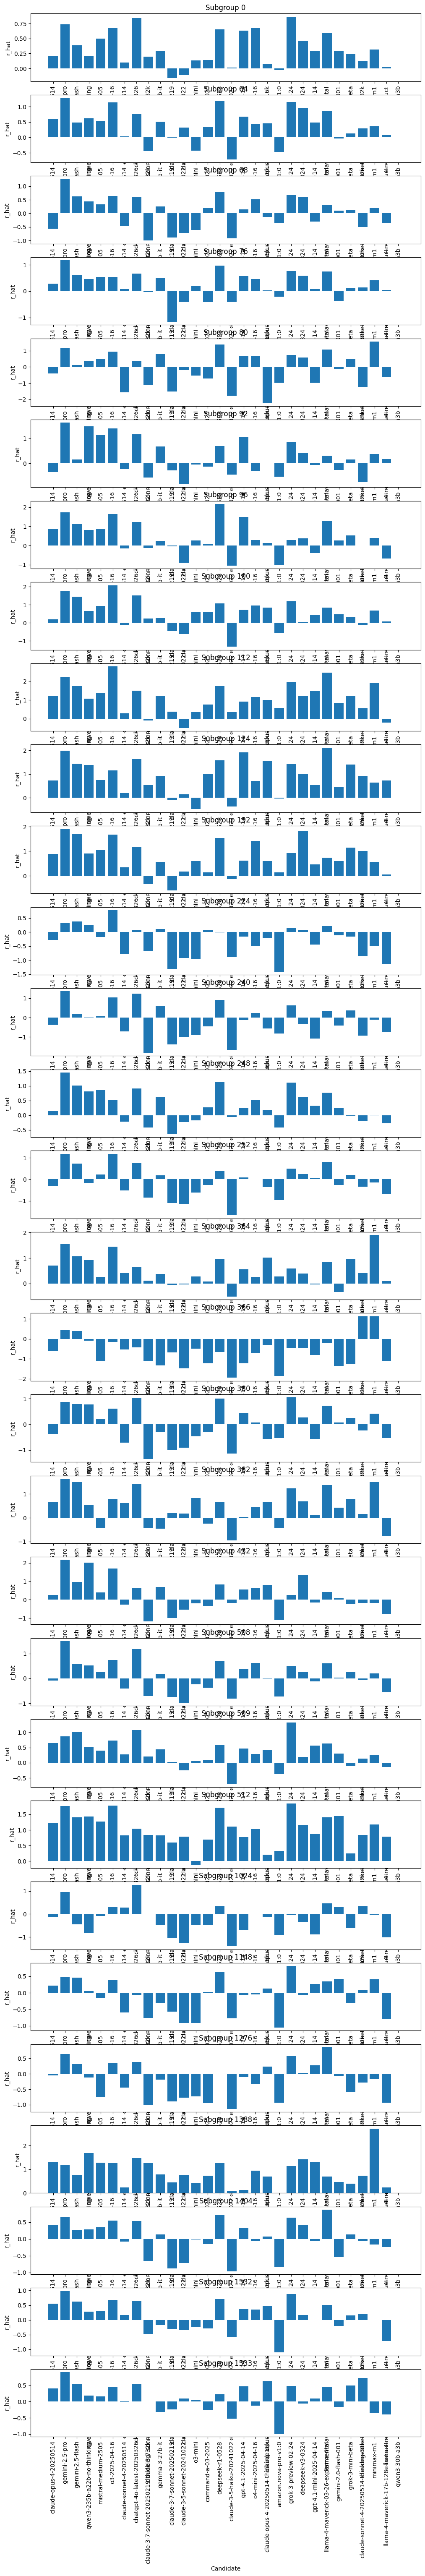

In [ ]:
import matplotlib.pyplot as plt

num_subgroups, num_candidates = population.population_utilities.shape
print(num_subgroups)
fig, axes = plt.subplots(num_subgroups, 1, figsize=(12, max(3, 2.5 * num_subgroups)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    subgroup = population.idx_to_subgroup[row_idx]
    r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3355948/493319653.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


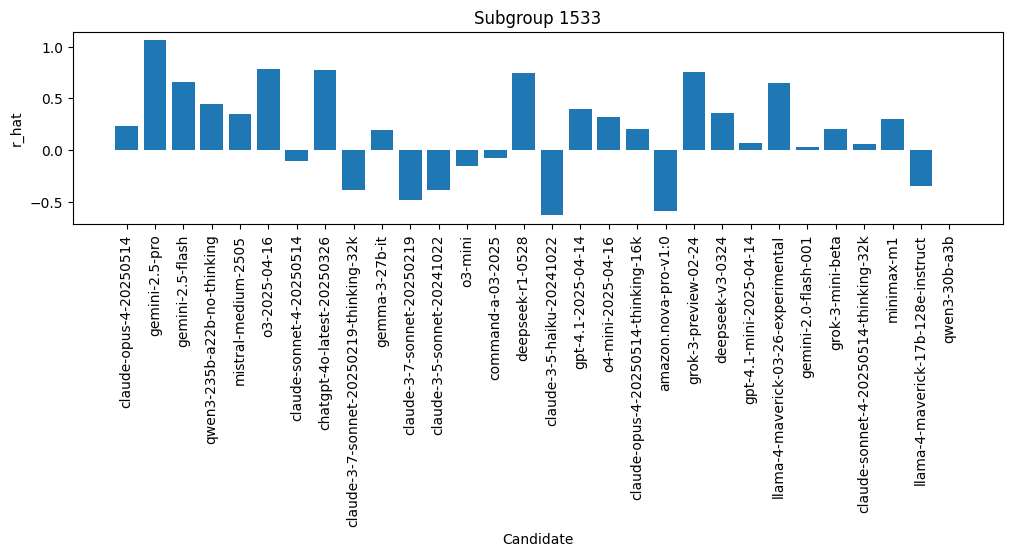

In [ ]:
import matplotlib.pyplot as plt

# num_subgroups, num_candidates = population.population_utilities.shape
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, 2.5), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    r_hat = population.single_latent_r_hat
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [ ]:
from utils_3 import misspecification_error

In [ ]:
population.subgroup_to_idx

{np.uint32(0): 0,
 np.uint32(64): 1,
 np.uint32(68): 2,
 np.uint32(76): 3,
 np.uint32(80): 4,
 np.uint32(92): 5,
 np.uint32(96): 6,
 np.uint32(100): 7,
 np.uint32(112): 8,
 np.uint32(124): 9,
 np.uint32(192): 10,
 np.uint32(224): 11,
 np.uint32(240): 12,
 np.uint32(248): 13,
 np.uint32(252): 14,
 np.uint32(364): 15,
 np.uint32(366): 16,
 np.uint32(380): 17,
 np.uint32(382): 18,
 np.uint32(432): 19,
 np.uint32(508): 20,
 np.uint32(509): 21,
 np.uint32(512): 22,
 np.uint32(1024): 23,
 np.uint32(1148): 24,
 np.uint32(1276): 25,
 np.uint32(1388): 26,
 np.uint32(1404): 27,
 np.uint32(1532): 28,
 np.uint32(1533): 29}

In [ ]:
data = pw.data_by_subgroups([1533])
winners = data['winners']
losers = data['losers']

In [ ]:
r_hat

array([ 0.23510597,  1.05940692,  0.66091282,  0.44180772,  0.34965093,
        0.78071997, -0.10046988,  0.77568164, -0.38565267,  0.19000925,
       -0.4783895 , -0.38956605, -0.15369679, -0.07374523,  0.74778563,
       -0.6311393 ,  0.40072285,  0.31598553,  0.20324589, -0.58432207,
        0.75480986,  0.35739505,  0.06441995,  0.64395712,  0.02813145,
        0.20075886,  0.05840979,  0.29716525, -0.34197581,  0.        ])

In [ ]:
r_hat = population.population_utilities[population.subgroup_to_idx[1533]]

misspecification_error(winners, losers, r_hat)

np.float64(222.63795346488143)

In [ ]:
avg_utils = population.avg_utilities

In [ ]:
misspecification_error(winners, losers, avg_utils)

np.float64(289.40231933199124)

In [ ]:
msspec_r_hat_sum = 0
msspec_avg_sum = 0

subgroup_size = 0

for i in range(len(population.subgroup_to_idx.keys())):
    subgroup = population.idx_to_subgroup[i]
    data = pw.data_by_subgroups([subgroup])
    winners = data['winners']
    losers = data['losers'] 
    # print(set(data['subgroups']))

    r_hat = population.population_utilities[i]
    r_hat = population._scale_r_hat(r_hat)
    single_r_hat = population._scale_r_hat(population.single_latent_r_hat)
    msspec_r_hat = misspecification_error(winners, losers, r_hat)
    msspec_avg = misspecification_error(winners, losers, single_r_hat)

    # if msspec_r_hat > msspec_avg:

    print('\nsubgroup:', subgroup)
    print('subgroup size:', len(winners))
    # print('r_hat:', r_hat)
    print('msspec r_hat:', msspec_r_hat)
    print('msspec avg_utils:', msspec_avg)

    print('normalized msspec r_hat:', msspec_r_hat / len(winners))
    print('normalized msspec avg_utils:', msspec_avg / len(winners))

    msspec_r_hat_sum += msspec_r_hat
    msspec_avg_sum += msspec_avg
    subgroup_size += len(winners)

print('\nmsspec_r_hat_sum', msspec_r_hat_sum)
print('msspec_avg_sum', msspec_avg_sum)
print('normalized_msspec_r_hat_sum', msspec_r_hat_sum / subgroup_size)
print('normalized_msspec_avg_sum', msspec_avg_sum / subgroup_size)
print('subgroup_size', subgroup_size)


subgroup: 0
subgroup size: 4091
msspec r_hat: 223.33284556557277
msspec avg_utils: 244.21177678289527
normalized msspec r_hat: 0.05459126022135731
normalized msspec avg_utils: 0.0596948855494733

subgroup: 64
subgroup size: 1620
msspec r_hat: 278.24271909450897
msspec avg_utils: 286.58490707595496
normalized msspec r_hat: 0.1717547648731537
normalized msspec avg_utils: 0.17690426362713269

subgroup: 68
subgroup size: 1588
msspec r_hat: 275.06896453070203
msspec avg_utils: 286.1534509745744
normalized msspec r_hat: 0.1732172320722305
normalized msspec avg_utils: 0.1801973872635859

subgroup: 76
subgroup size: 1249
msspec r_hat: 270.37335268189844
msspec avg_utils: 270.26343052311995
normalized msspec r_hat: 0.21647185963322532
normalized msspec avg_utils: 0.21638385149969572

subgroup: 80
subgroup size: 412
msspec r_hat: 176.35510160523773
msspec avg_utils: 184.66709733651516
normalized msspec r_hat: 0.42804636311950905
normalized msspec avg_utils: 0.4482211100400853

subgroup: 92
subg

In [ ]:
from utils_3 import borda_from_population_utilities

In [ ]:
borda_scores, ranking = borda_from_population_utilities(population.population_utilities, population.voter_distr, beta=0.5)

In [ ]:
true_ranking = np.argsort(-population.avg_utilities)

In [ ]:
from utils_3 import leaderboard_dist

In [ ]:
leaderboard_dist(ranking, true_ranking, population.avg_utilities)

(np.float64(1.0), np.int64(0))

In [ ]:
ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [ ]:
true_ranking

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       26, 22, 24, 29, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [ ]:
train_data = ds['train']

In [ ]:
population.idx_to_subgroup[0]

np.uint32(0)

In [ ]:
data_0 = pw.data_by_subgroups([0])
print(data_0['winners'])
print(data_0['losers'])

[ 4  1 15 ... 20  7 23]
[ 6  8 26 ...  4  1 14]


In [ ]:
!pip install choix
import choix


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
pw.M

30

In [ ]:
wl_matrix = np.zeros((pw.M, pw.M))

In [ ]:
for i in range(len(data_0['winners'])):
    wl_matrix[data_0['winners'][i], data_0['losers'][i]] += 1

print(wl_matrix)

[[ 0.  4. 16.  5.  8.  5.  5.  3.  5. 11.  9.  9.  8.  7.  6.  4.  8.  5.
   4. 10.  7. 11.  9.  7.  3.  7.  2.  5. 10.  8.]
 [14.  0.  7. 11. 11.  6.  9.  6. 11.  4. 10.  1. 11. 14.  6. 12.  8.  2.
  11.  8.  6.  4.  8.  5.  3.  6.  7.  6.  6.  9.]
 [10.  8.  0.  8.  4.  9.  7.  3.  8.  5. 10. 10.  4.  7.  3.  6.  6.  3.
   4.  9.  3.  6.  6.  6.  6.  3.  2.  6.  5.  3.]
 [ 7.  2.  7.  0.  8.  3.  5.  3.  3.  6.  4.  6.  6.  7.  5.  2.  5.  4.
   4.  7.  7.  4.  5.  6.  5.  4. 12.  2.  3.  4.]
 [15.  9. 12.  9.  0.  5. 14.  6.  9.  6.  6.  4.  9.  8.  8.  8.  7.  5.
   6.  9.  3.  4.  8.  2.  4.  8.  7.  6.  3.  4.]
 [ 8.  4.  8.  9.  7.  0.  8.  5.  9.  5.  7. 12.  4. 11.  5.  8.  4.  3.
   8.  5.  7.  4.  3.  2.  4.  6.  5.  7.  7.  6.]
 [ 7.  7.  5.  6.  5.  3.  0.  4. 10.  5.  5.  3.  3. 11.  6.  7.  6.  2.
   1.  6.  2.  2.  3.  5.  3.  5.  3.  1.  2.  8.]
 [12.  7.  8.  6. 10.  9.  3.  0.  6.  8. 14. 11.  9.  8.  3.  8.  6. 10.
   4.  3.  5.  5.  7.  1.  7.  3.  2.  3.  5.  6.]


In [ ]:
choix_r_hat = choix.ilsr_pairwise_dense(wl_matrix, alpha=0.1)
print(population._scale_r_hat(choix_r_hat))
scaled_choix_r_hat = population._scale_r_hat(choix_r_hat)

[0.35334758 0.88328103 0.52484143 0.3571046  0.67864713 0.82450501
 0.2761499  1.         0.38890819 0.45597164 0.         0.05909179
 0.31702265 0.31197994 0.80551078 0.1707395  0.74264823 0.82121795
 0.22943135 0.14986905 0.94629653 0.58158346 0.43303216 0.75174148
 0.45938166 0.39612444 0.33760655 0.46182137 0.20822278 0.18957023]


In [ ]:
print(population._scale_r_hat(population.population_utilities[0]))
scaled_weighed_r_hat = population._scale_r_hat(population.population_utilities[0])

[0.36329615 0.87383073 0.53500638 0.36502898 0.64187505 0.81330827
 0.25338532 0.97887082 0.34915579 0.44616321 0.         0.05240912
 0.28995391 0.2935983  0.79180916 0.17209125 0.77448408 0.81047367
 0.2313988  0.13235207 1.         0.61127113 0.43503635 0.73437554
 0.44141898 0.39684842 0.28415709 0.46182047 0.18583531 0.15783567]


In [ ]:
def bt_neg_log_likelihood(r_free, winners, losers, n_items, cand_distr=None, beta=1.0):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = beta * (r[winners] - r[losers])
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    # if cand_distr is not None:
    #     weighted_terms = np.logaddexp(0.0, -diff) / (cand_distr[winners] * cand_distr[losers])
    # else:
    weighted_terms = np.logaddexp(0.0, -diff)
    nll = np.sum(weighted_terms) # TODO: normalize by probability of sampling pair
    return nll

In [ ]:
from scipy.optimize import minimize

x0 = np.zeros(pw.M - 1)

result = minimize(
    bt_neg_log_likelihood,
    x0,
    args=(data_0['winners'], data_0['losers'], pw.M - 1, None),
    method="L-BFGS-B"
)

if not result.success:
    raise RuntimeError(f"Bradley-Terry fit failed: {result.message}")

r_hat = np.concatenate([result.x, [0.0]])

print(population._scale_r_hat(r_hat))
scaled_unweighed_r_hat = population._scale_r_hat(r_hat)

[0.35230571 0.87613141 0.51979795 0.35425468 0.67256757 0.81968093
 0.27426111 1.         0.38543511 0.4517253  0.         0.05821308
 0.31400501 0.30942696 0.80329863 0.16691732 0.74009343 0.81960462
 0.22463635 0.14638459 0.94817146 0.57677341 0.42888125 0.75087632
 0.45487272 0.39038548 0.33126063 0.45546788 0.20387979 0.18446894]


In [ ]:
distr = np.zeros(pw.M)
for i in range(len(data_0['winners'])):
    distr[data_0['winners'][i]] += 1
    distr[data_0['losers'][i]] += 1

# print(distr)

In [ ]:
def bt_neg_log_likelihood_weighted(r_free, winners, losers, n_items, cand_distr=None, beta=1.0):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = beta * (r[winners] - r[losers])
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    # if cand_distr is not None:
    weighted_terms = np.logaddexp(0.0, -diff) / (cand_distr[winners] * cand_distr[losers])
    # else:
    # weighted_terms = np.logaddexp(0.0, -diff)
    nll = np.sum(weighted_terms) # TODO: normalize by probability of sampling pair
    return nll

In [ ]:
from scipy.optimize import minimize

x0 = np.zeros(pw.M - 1)

result = minimize(
    bt_neg_log_likelihood_weighted,
    x0,
    args=(data_0['winners'], data_0['losers'], pw.M - 1, distr),
    method="L-BFGS-B"
)

if not result.success:
    raise RuntimeError(f"Bradley-Terry fit failed: {result.message}")

r_hat = np.concatenate([result.x, [0.0]])

print(population._scale_r_hat(r_hat))
scaled_weighed_r_hat = population._scale_r_hat(r_hat)

[0.37316703 0.88248817 0.55020485 0.36228593 0.65785292 0.81884377
 0.25240373 0.98428837 0.35590483 0.45740415 0.         0.04284571
 0.30004359 0.28252958 0.8078957  0.18047094 0.77461712 0.83022771
 0.25302558 0.13484733 1.         0.619897   0.44465691 0.73645557
 0.45049476 0.40027565 0.29288059 0.4660178  0.18742439 0.15420582]


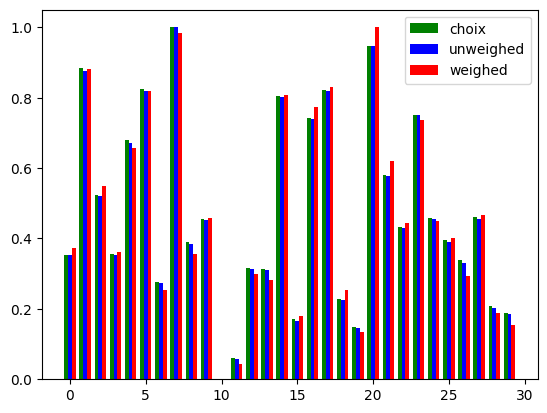

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(len(scaled_choix_r_hat))
width = 0.25

plt.bar(x - width, scaled_choix_r_hat, width=width, color='green', label='choix')
plt.bar(x, scaled_unweighed_r_hat, width=width, color='blue', label='unweighed')
plt.bar(x + width, scaled_weighed_r_hat, width=width, color='red', label='weighed')

plt.legend()
plt.show()

In [ ]:
print(population.population_utilities.min(axis=0).shape)
population.population_utilities.max(axis=1)

(30,)


array([0.86454022, 1.28439169, 1.26407977, 1.17374621, 1.56005156,
       1.6096111 , 2.16457871, 2.08226926, 2.77692131, 2.1143099 ,
       1.90867532, 0.77857082, 1.35308596, 1.45449846, 1.18677842,
       1.90254662, 1.13513435, 1.04565062, 1.63396289, 2.16379691,
       1.49975597, 1.32689216, 1.84458539, 1.26841008, 0.8084939 ,
       0.85620595, 2.71261988, 0.86979568, 0.98205463, 0.9024312 ])